# Visual Data Science Notebook on Renewable Energy Insight
This notebook helps to work through the pipeline of getting interesting information and metrics on renewable energies

## Return on investment of different countries

In [ ]:

import sys
print(sys.executable)
import pandas as pd
import numpy as np
import chardet
import seaborn as snus
import matplotlib.pyplot as plt
from enum import Enum   
DATA_FOLDER = "data/"
SELECTED_COUNTRIES = ["Germany","Mexico", "Brazil","Austria", "France", "Türkiye", "Japan", "Egypt" ] #"Italy", "Spain", "United Kingdom", "Netherlands", "Sweden"
IAE_MEMBERS = [
    "Australia", "Austria", "Belgium", "Canada", "Czechia", "Denmark",
    "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Japan", "Korea", "Latvia", "Lithuania",
    "Luxembourg", "Mexico", "New Zealand", "Norway", "Poland", "Portugal",
    "Slovak Republic", "Spain", "Sweden", "Switzerland", "The Netherlands",
    "Türkiye", "United Kingdom", "United States"
]
IAE_ACCESSION = [
    "Chile", "Colombia", "Costa Rica", "Israel"
]
IAE_ASSOCIATION = [
    "Argentina", "Brazil", "China", "Egypt", "India", "Indonesia",
    "Kenya", "Morocco", "Senegal", "Singapore", "South Africa",
    "Thailand", "Ukraine"
]
IAE_COMBINED = IAE_MEMBERS + IAE_ACCESSION + IAE_ASSOCIATION

class RDD_TYPE(Enum):
    TOTAL = "TOTAL"
    RENEWABLE = "RENEWABLE"
    FOSSILFUEL = "FOSSILFUEL"


/home/mozi/miniconda3/envs/vds/bin/python


In [118]:
# with open(DATA_FOLDER + 'capacity-generation-emission.csv', 'rb') as f:
#     result = chardet.detect(f.read())
#     encoding = result['encoding']
capacity_generation_emission_content = pd.read_csv(DATA_FOLDER + "capacity-generation-emission.csv", encoding='utf-8')
#print(capacity_generation_emission_content.head())

# with open(DATA_FOLDER + 'public-investments.csv', 'rb') as f:
#     result = chardet.detect(f.read())
#     encoding = result['encoding']
# print(f"Detected encoding: {encoding}")
public_investment_content = pd.read_csv(DATA_FOLDER + 'public-investments.csv', encoding='iso-8859-1')

# with open(DATA_FOLDER + 'european-energy-prices.csv', 'rb') as f:
#     result = chardet.detect(f.read())
#     encoding = result['encoding']
european_energy_prices_content = pd.read_csv(DATA_FOLDER + 'european-energy-prices.csv', encoding='iso-8859-1')
#print(european_energy_prices_content.head())

gdp_population_content = pd.read_csv(DATA_FOLDER + "gdp-population.csv")

rdd_content = pd.read_csv(DATA_FOLDER + "rdd-total-fossile-renewable.csv")








In [119]:
print("Capacity generation emission columns:")
print(capacity_generation_emission_content.columns)
capacity_generation_emission_content = capacity_generation_emission_content.drop(
    columns=[
        "EU","OECD","G7","G20","ASEAN"
        ]
)
capacity_generation_emission_content = capacity_generation_emission_content.rename(columns={"Area": "Country/Region"})
print("Cleaned capacity generation emission columns:")
print(capacity_generation_emission_content.columns)

print("\n")

print("Public rd&d investment columns:")
print(rdd_content.columns)
rdd_content = rdd_content.drop(
    columns=[
        "STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "ACTION", "COUNTRY", "FREQUENCY", "Frequency",
        "RDD_SECTOR","Technology", "RDD_TYPE","Sector", "Type", "UNIT","Time Period","Observation value", "QUALIFIER", "Qualifier",
        "CONF_STATUS", "Confidential Status", "Decimals","Unit multiplier","DECIMALS"
    ]
)
rdd_content = rdd_content.rename(columns={"RDD_TECH": "Type", "TIME_PERIOD": "Year", "OBS_VALUE": "Investment Amount (Million US$)", "UNIT_MULT": "Unit Multiplier"})
print("Cleaned public rd&d investment columns:")
print(rdd_content.columns)

print("\n")

print("Gdp and population columns:")
print(gdp_population_content.columns)
#Remove unneeded columns from gdp_population_content
gdp_population_content = gdp_population_content.drop(
    columns=[   
             "Country Code", "Series Code"
    ]
)

#Remove [YRXXXX] from column names
gdp_population_content.columns = gdp_population_content.columns.str.replace(r'\[YR\d{4}\]', '', regex=True).str.strip()
gdp_population_content = pd.melt(gdp_population_content, id_vars=['Country Name', 'Series Name'],value_vars=[col for col in gdp_population_content.columns if col not in ['Country Name', 'Series Name']], var_name='Year', value_name='Value')
gdp_population_content['Value'] = pd.to_numeric(gdp_population_content['Value'], errors='coerce')
print("Cleaned gdp and population columns:")
print(gdp_population_content.columns)

Capacity generation emission columns:
Index(['Area', 'ISO 3 code', 'Year', 'Area type', 'Continent', 'Ember region',
       'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory',
       'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change'],
      dtype='object')
Cleaned capacity generation emission columns:
Index(['Country/Region', 'ISO 3 code', 'Year', 'Area type', 'Continent',
       'Ember region', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value',
       'YoY absolute change', 'YoY % change'],
      dtype='object')


Public rd&d investment columns:
Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'COUNTRY',
       'Country/Region', 'FREQUENCY', 'Frequency', 'RDD_SECTOR', 'Sector',
       'RDD_TECH', 'Technology', 'RDD_TYPE', 'Type', 'UNIT', 'Unit',
       'TIME_PERIOD', 'Time Period', 'OBS_VALUE', 'Observation value',
       'QUALIFIER', 'Qualifier', 'CONF_STATUS', 'Confidential Status',
       'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'D

In [120]:
def get_average_european_energy_price(country_list):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = european_energy_prices_content[european_energy_prices_content['Country'] == country].copy()
        country_data['Year'] = pd.to_datetime(country_data['Date']).dt.year
        country_data['Avarage Price'] = country_data.groupby(['Year'])['Price (EUR/MWhe)'].transform('mean')
        country_data = country_data.drop(['Date', 'Price (EUR/MWhe)'], axis=1)
        country_data = country_data.drop_duplicates()
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
       

    return country_list_df

In [121]:
country_prices = [get_average_european_energy_price(country) for country in [["Austria","Germany"]]]
print(country_prices)

[    Country ISO3 Code  Year  Avarage Price
0   Austria       AUT  2015      31.764167
1   Austria       AUT  2016      28.956667
2   Austria       AUT  2017      34.419167
3   Austria       AUT  2018      40.891667
4   Austria       AUT  2019      40.137500
5   Austria       AUT  2020      33.090833
6   Austria       AUT  2021     107.598333
7   Austria       AUT  2022     262.435000
8   Austria       AUT  2023     102.389167
9   Austria       AUT  2024      81.182500
10  Austria       AUT  2025      95.840000
11  Germany       DEU  2015      31.764167
12  Germany       DEU  2016      28.956667
13  Germany       DEU  2017      34.638333
14  Germany       DEU  2018      43.463333
15  Germany       DEU  2019      37.814167
16  Germany       DEU  2020      30.372500
17  Germany       DEU  2021      97.275000
18  Germany       DEU  2022     235.530833
19  Germany       DEU  2023      95.390833
20  Germany       DEU  2024      77.746667
21  Germany       DEU  2025      88.682000]


In [122]:
def get_yearly_public_investment(country_list):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = public_investment_content[public_investment_content['Country/area'] == country].copy()
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def get_countries_with_most_data(year=None, top_n=10, technology='Multiple renewables'):
    # Count countries that have a non-missing / non-'-' value in the Public Investments column.
    col = 'Public Investments (2022 Million USD)'
    df = public_investment_content.copy()

    # optional year filter if the dataset has a Year column
    if year is not None and 'Year' in df.columns:
        df = df[df['Year'] == year]
    # consider non-null and not the hyphen placeholder
    valid = df[df[col].notna() & (df[col] != '-')]

    # count valid rows per country and return top N countries
    top_countries = valid['Country/area'].value_counts().head(top_n).index.tolist()
    num_valid_rows = valid['Country/area'].value_counts().head(top_n).tolist()
    top_countries = (top_countries, num_valid_rows)
    return top_countries

def get_investment_by_country_and_year(country_list, technology='Multiple renewables'):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = public_investment_content[public_investment_content['Country/area'] == country].copy()
        country_data = country_data[country_data['Technology'] == technology]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    country_list_df.rename(columns={'Public Investments (2022 Million USD)': 'Public Investments (Mill USD)',"Country/area": "Country"}, inplace=True)
    country_list_df.drop(['Technology'], axis=1, inplace=True)
    return country_list_df

In [123]:
investments = get_yearly_public_investment(SELECTED_COUNTRIES)
# print(investments)

top_countries = get_countries_with_most_data(top_n=50)
print(top_countries)

investment = get_investment_by_country_and_year(SELECTED_COUNTRIES) 
# yearly_investment = investment.pivot(index='Year', columns='Country', values='Public Investments (Mill USD)')
# print(yearly_investment)
investment['Public Investments (Mill USD)'] = pd.to_numeric(
    investment['Public Investments (Mill USD)'], 
    errors='coerce'  # Converts '-' to NaN
)
investment_clean = investment.dropna(subset=['Public Investments (Mill USD)'])
pd.set_option('display.max_rows', None)
print(investment_clean)

(['Brazil', 'India', 'Residual/unallocated ODA: Sub-Saharan Africa', 'Indonesia', 'Kenya', 'China', 'Viet Nam', 'United Republic of Tanzania (the)', 'Ethiopia', 'Uganda', 'Nepal', 'Egypt', 'Morocco', 'Peru', 'Bolivia (Plurinational State of)', 'Pakistan', 'Philippines (the)', 'Residual/unallocated ODA: Eastern and South-eastern Asia', 'South Africa', 'Argentina', 'Mexico', 'Ghana', 'Nicaragua', 'Senegal', 'Zambia', 'Madagascar', 'Thailand', 'Ecuador', 'Serbia', 'Bosnia and Herzegovina', 'Georgia', 'Rwanda', 'Mozambique', 'Cuba', 'Burkina Faso', 'Bangladesh', 'Colombia', 'Tï¿½rkiye', 'Sri Lanka', 'Chile', 'Tunisia', 'Cambodia', 'Nigeria', 'Mali', 'Dominican Republic (the)', 'Cameroon', 'Democratic Republic of the Congo (the)', 'Ukraine', 'Malawi', 'Honduras'], [138, 120, 103, 102, 99, 96, 88, 88, 86, 85, 77, 75, 74, 74, 73, 73, 71, 70, 70, 69, 68, 66, 65, 63, 61, 61, 61, 61, 61, 60, 60, 58, 58, 57, 57, 57, 57, 56, 56, 56, 54, 53, 52, 52, 52, 52, 51, 51, 50, 50])
     Country  Year  Publ

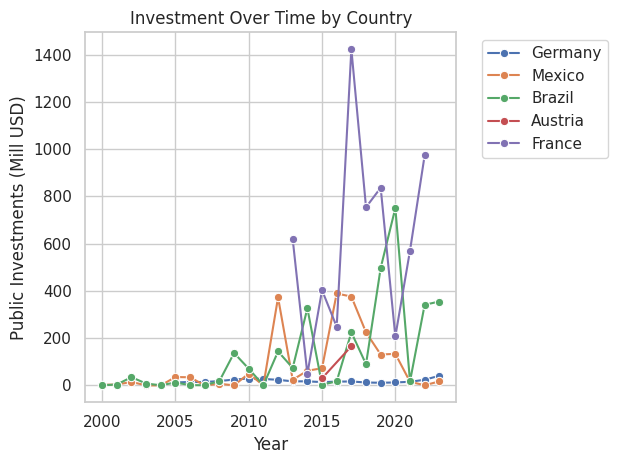

In [124]:
snus.set_theme(style="whitegrid")
snus.lineplot(
    data=investment_clean, 
    x='Year', 
    y='Public Investments (Mill USD)', 
    hue='Country', 
    marker='o'
)
plt.title('Investment Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [125]:
def get_rdd_investment(country_list, type: RDD_TYPE):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = rdd_content[rdd_content['Country/Region']==country]
        rdd_type = country_data[country_data['Type']==type.value]
        country_list_df = pd.concat([country_list_df, rdd_type], ignore_index=True)
    print(country_list_df.columns)
    return country_list_df

print(get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.RENEWABLE))

Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
   Country/Region       Type                                      Unit  Year  \
0         Germany  RENEWABLE  USD (constant prices and exchange rates)  2000   
1         Germany  RENEWABLE  USD (constant prices and exchange rates)  2001   
2         Germany  RENEWABLE  USD (constant prices and exchange rates)  2002   
3         Germany  RENEWABLE  USD (constant prices and exchange rates)  2003   
4         Germany  RENEWABLE  USD (constant prices and exchange rates)  2004   
5         Germany  RENEWABLE  USD (constant prices and exchange rates)  2005   
6         Germany  RENEWABLE  USD (constant prices and exchange rates)  2006   
7         Germany  RENEWABLE  USD (constant prices and exchange rates)  2007   
8         Germany  RENEWABLE  USD (constant prices and exchange rates)  2008   
9         Germany  RENEWABLE  USD (constant prices and exchange rat

Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')


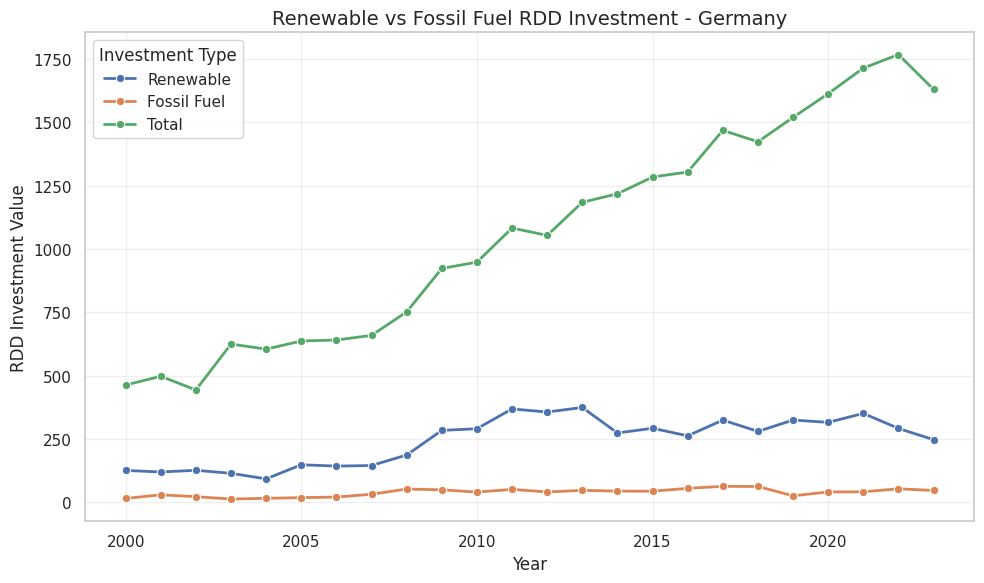

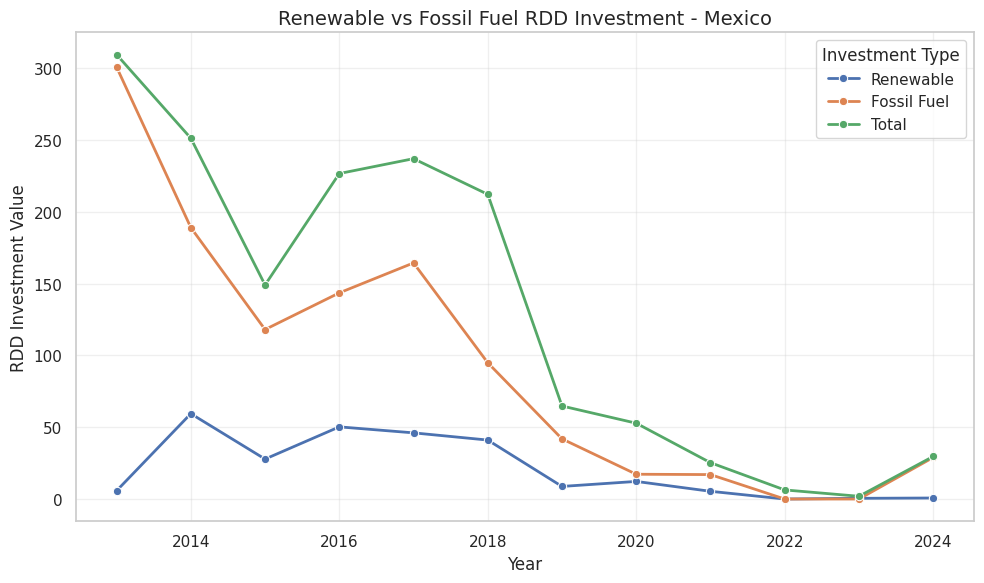

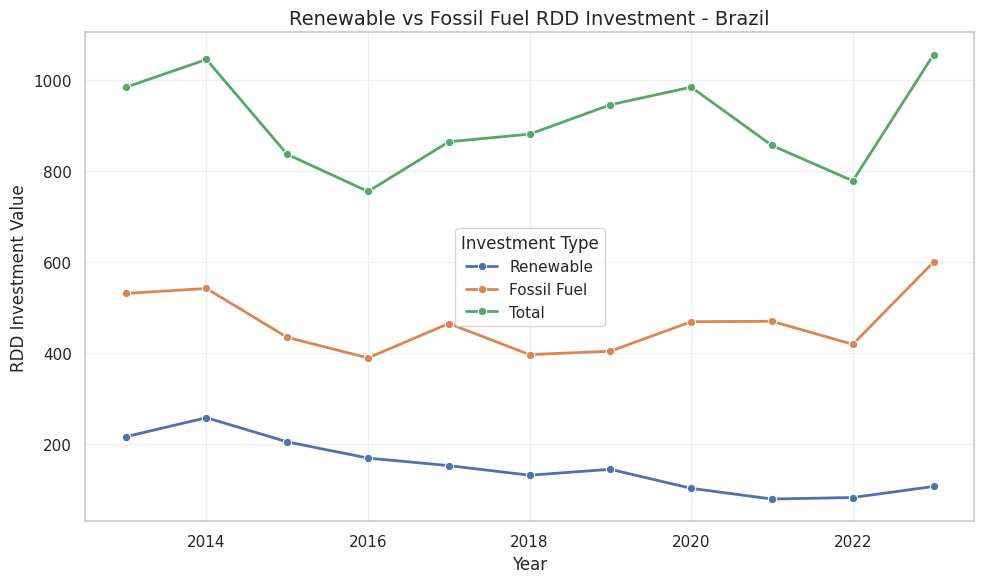

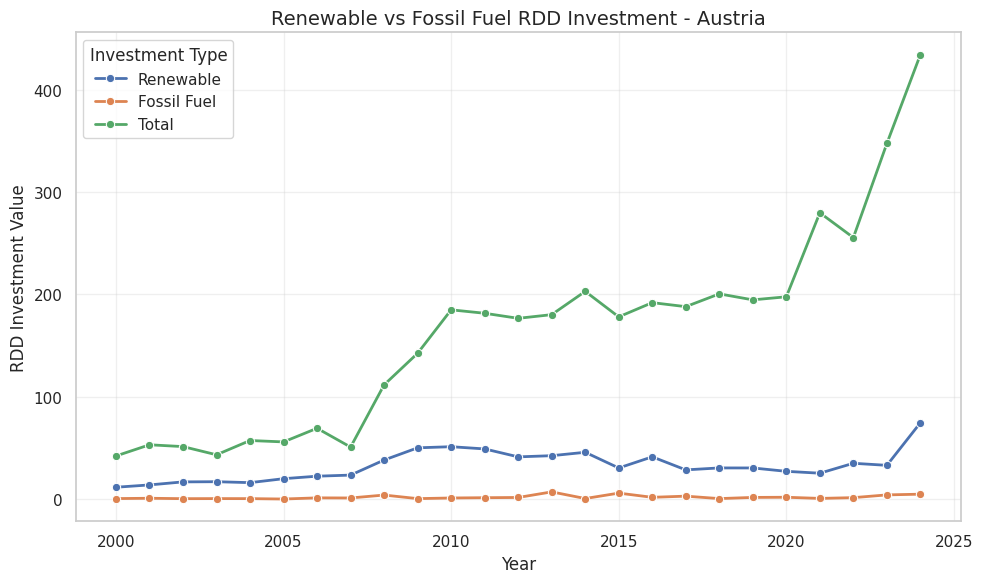

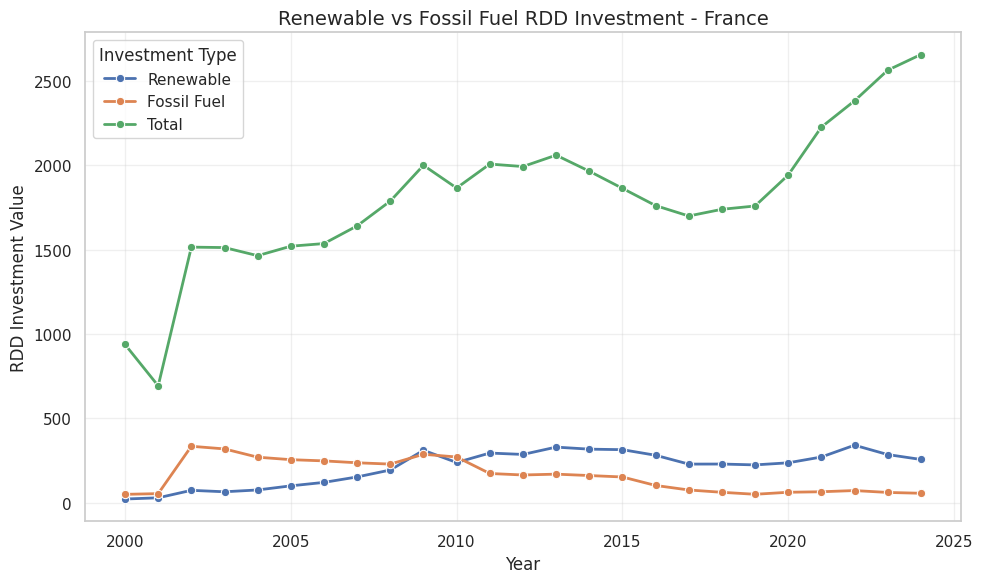

In [126]:
selected_renewable_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.RENEWABLE)
selected_fossilfuel_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.FOSSILFUEL)
selected_total_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.TOTAL)
selected_renewable_rdd['Investment_Type'] = 'Renewable'
selected_fossilfuel_rdd['Investment_Type'] = 'Fossil Fuel'
selected_total_rdd['Investment_Type'] = 'Total'
combined_rdd = pd.concat([selected_renewable_rdd, selected_fossilfuel_rdd, selected_total_rdd], ignore_index=True)

#Plot Renewable vs Fossilfuel RDD Investment Over Time by Country

for country in SELECTED_COUNTRIES:
    country_data = combined_rdd[combined_rdd['Country/Region'] == country]
    
    plt.figure(figsize=(10, 6))
    snus.lineplot(
        data=country_data,
        x='Year',
        y='Investment Amount (Million US$)',
        hue='Investment_Type',
        marker='o',
        linewidth=2
    )
    plt.title(f'Renewable vs Fossil Fuel RDD Investment - {country}', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('RDD Investment Value', fontsize=12)
    plt.legend(title='Investment Type', loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

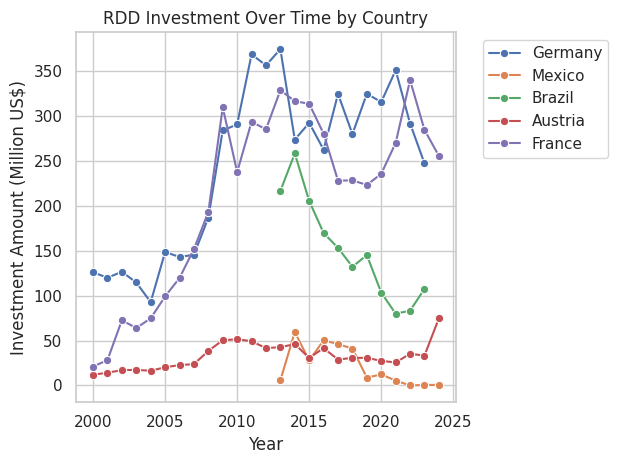

In [127]:
snus.lineplot(
    data=selected_renewable_rdd, 
    x='Year', 
    y='Investment Amount (Million US$)', 
    hue='Country/Region', 
    marker='o'
)
plt.title('RDD Investment Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [128]:
def get_country_gdp_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'GDP (current US$)')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'GDP'})
    return grouped

def get_country_population_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'Population, total')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'Population'})
    return grouped

def get_combined_gdp(country_list):
    gdp_data = get_country_gdp_sum(country_list)
    gdp_data = gdp_data.groupby('Year')['GDP'].sum().reset_index()
    return gdp_data

def calculate_investment_per_gdp(investment_df, gdp_df,
                                 inv_country_col='Country/Region',
                                 inv_year_col='Year',
                                 gdp_country_col='Country Name',   # optional
                                 gdp_year_col='Year',
                                 investment_col='Investment Amount (Million US$)',
                                 gdp_col='GDP'):
    inv = investment_df.copy()
    gdp = gdp_df.copy()

    # Harmonize dtypes
    inv[inv_year_col] = pd.to_numeric(inv[inv_year_col], errors='coerce').astype('Int64')
    gdp[gdp_year_col] = pd.to_numeric(gdp[gdp_year_col], errors='coerce').astype('Int64')

    inv[investment_col] = pd.to_numeric(inv[investment_col], errors='coerce')
    gdp[gdp_col]       = pd.to_numeric(gdp[gdp_col],       errors='coerce')

    # Clean strings
    if inv_country_col in inv.columns:
        inv[inv_country_col] = inv[inv_country_col].astype(str).str.strip()
    if gdp_country_col in gdp.columns:
        gdp[gdp_country_col] = gdp[gdp_country_col].astype(str).str.strip()

    # Decide merge keys
    has_gdp_country = gdp_country_col in gdp.columns
    if has_gdp_country:
        merge_left_on  = [inv_country_col, inv_year_col]
        merge_right_on = [gdp_country_col, gdp_year_col]
        validate_rule  = 'many_to_one'   # each (country, year) -> one GDP row
    else:
        merge_left_on  = [inv_year_col]
        merge_right_on = [gdp_year_col]
        validate_rule  = 'many_to_one'

    merged = pd.merge(
        inv, gdp,
        left_on=merge_left_on,
        right_on=merge_right_on,
        how='left',
        validate=validate_rule
    )

    # Avoid divide-by-zero
    denom = merged[gdp_col].replace(0, np.nan)
    merged['Investment_per_GDP'] = merged[investment_col] * np.power(10, 6) / denom

    # Pick tidy columns to return
    keep_cols = []
    if inv_country_col in merged.columns:
        keep_cols.append(inv_country_col)
    keep_cols += [inv_year_col, investment_col, gdp_col, 'Investment_per_GDP']

    return merged[keep_cols]

def calculate_relative_investment_per_gdp(country_list,comparison_country,type: RDD_TYPE):

    country_list_investment = get_rdd_investment(country_list, type)
    country_list_gdp = get_country_gdp_sum(country_list)
    country_list_investment_per_gdp = calculate_investment_per_gdp(country_list_investment, country_list_gdp)

    comparison_country_investment = get_rdd_investment([comparison_country], type)
    if(comparison_country == 'Total IEA'): 
        comparison_country_gdp = get_combined_gdp(IAE_COMBINED)
    else:
        comparison_country_gdp = get_country_gdp_sum([comparison_country])
    
    comparison_country_investment_per_gdp = calculate_investment_per_gdp(comparison_country_investment, comparison_country_gdp)

    merged = country_list_investment_per_gdp.merge(comparison_country_investment_per_gdp, on='Year', suffixes=('_country', '_comparison'))
    merged['Relative_Investment_per_GDP'] = (merged['Investment_per_GDP_country'] / merged['Investment_per_GDP_comparison']) - 1
    merged.drop(columns=['Investment Amount (Million US$)_country', 'GDP_country',
       'Investment_per_GDP_country', 'Country/Region_comparison',
       'Investment Amount (Million US$)_comparison', 'GDP_comparison',
       'Investment_per_GDP_comparison',], inplace=True)
    merged.rename(columns={'Country/Region_country': 'Country/Region'}, inplace=True)
    return merged


    


    

Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Type', 'Unit', 'Year',
       'Investment Amount (Million US$)', 'Unit Multiplier'],
      dtype='object')
Index(['Country/Region', 'Year', 'Relative_Investment_per_GDP'], dtype='object')


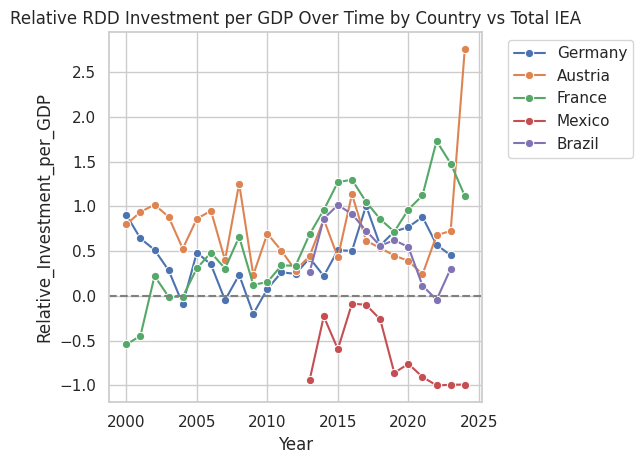

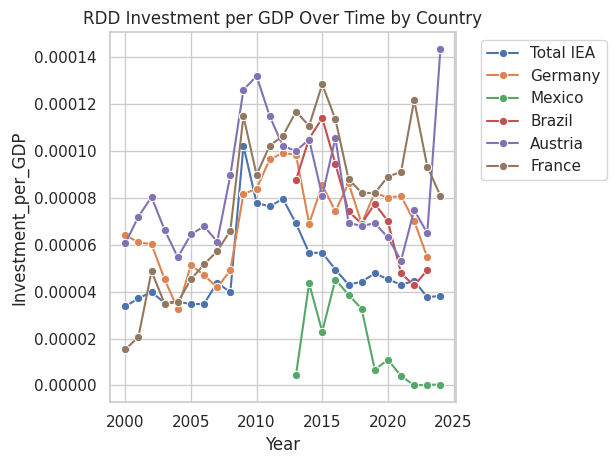

In [129]:
iae_renewable_investment = get_rdd_investment(['Total IEA'], RDD_TYPE.RENEWABLE)
iae_gdp = get_combined_gdp(IAE_COMBINED)
iae_investment_gdp_scaled = calculate_investment_per_gdp(iae_renewable_investment, iae_gdp)

selected_countries_renewable_investment = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.RENEWABLE)
selected_countries_gdp = get_country_gdp_sum(SELECTED_COUNTRIES)
selected_countries_investment_gdp_scaled = calculate_investment_per_gdp(selected_countries_renewable_investment, selected_countries_gdp)

relative_investments = calculate_relative_investment_per_gdp(SELECTED_COUNTRIES,'Total IEA', RDD_TYPE.RENEWABLE)
print(relative_investments.columns)
snus.lineplot(
    data=relative_investments,
    x='Year',
    y='Relative_Investment_per_GDP',
    hue='Country/Region',
    marker='o'
)
plt.title('Relative RDD Investment per GDP Over Time by Country vs Total IEA')
plt.axhline(0, color='gray', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

combined_investment_gdp = pd.concat([iae_investment_gdp_scaled, selected_countries_investment_gdp_scaled], ignore_index=True)
snus.lineplot(
    data=combined_investment_gdp, 
    x='Year', 
    y='Investment_per_GDP', 
    hue='Country/Region', 
    marker='o'
)
plt.title('RDD Investment per GDP Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



